filtering: CRMLSSold202409.csv
filtering: CRMLSSold202408.csv
filtering: CRMLSSold202501_filled.csv
filtering: CRMLSSold202406_filled.csv
filtering: CRMLSSold202509.csv
filtering: CRMLSSold202508.csv
filtering: CRMLSSold202503.csv
filtering: CRMLSSold202502.csv
filtering: CRMLSSold202405_filled.csv
filtering: CRMLSSold202505.csv
filtering: CRMLSSold202511.csv
filtering: CRMLSSold202510.csv
filtering: CRMLSSold202504.csv
filtering: CRMLSSold202512.csv
filtering: CRMLSSold202506.csv
filtering: CRMLSSold202507.csv
filtering: CRMLSSold202602.csv
filtering: CRMLSSold202603.csv
filtering: CRMLSSold202601.csv
filtering: CRMLSSold202412.csv
filtering: CRMLSSold202604.csv
filtering: CRMLSSold202605.csv
filtering: CRMLSSold202407_filled.csv
filtering: CRMLSSold202411.csv
filtering: CRMLSSold202410.csv


<Figure size 1500x1000 with 0 Axes>

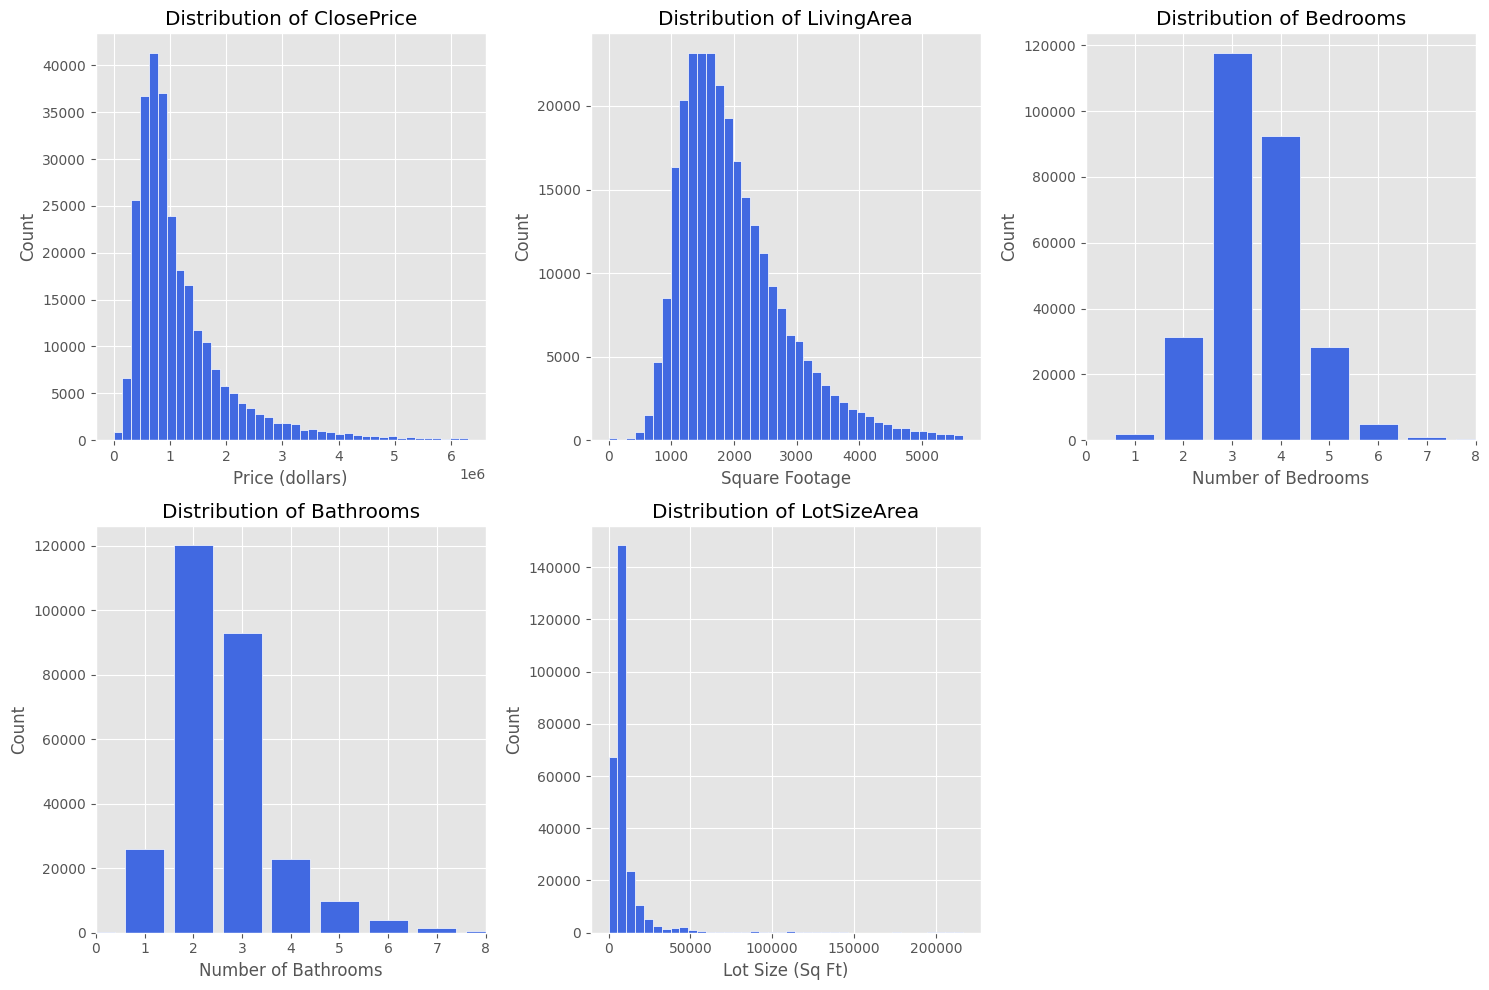

In [15]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")

plt.figure(figsize=(15, 10))

all_files = glob.glob("raw_data/CRMLSSold*.csv")

all_filtered_data = []

for file_path in all_files:
    print(f"filtering: {os.path.basename(file_path)}")
    
    current_df = pd.read_csv(file_path, low_memory=False)
    
    current_filtered = current_df[(current_df["PropertyType"] == "Residential") & (
        current_df["PropertySubType"] == "SingleFamilyResidence"
    )]
    
    subset = current_filtered[[
        "ClosePrice", 
        "LivingArea", 
        "BedroomsTotal", 
        "BathroomsTotalInteger", 
        "LotSizeArea"
    ]]
    
    all_filtered_data.append(subset)

final_eda_df = pd.concat(all_filtered_data, ignore_index=True)

plot_df = final_eda_df.copy()

price_99 = plot_df["ClosePrice"].quantile(0.99)
sqft_99 = plot_df["LivingArea"].quantile(0.99)
lot_99 = plot_df["LotSizeArea"].quantile(0.99)


plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.hist(plot_df[plot_df["ClosePrice"] <= price_99]["ClosePrice"], bins=40, color="royalblue", edgecolor="white")
plt.title("Distribution of ClosePrice")
plt.xlabel("Price (dollars)")
plt.ylabel("Count")

plt.subplot(2, 3, 2)
plt.hist(plot_df[plot_df["LivingArea"] <= sqft_99]["LivingArea"], bins=40, color="royalblue", edgecolor="white")
plt.title("Distribution of LivingArea")
plt.xlabel("Square Footage")
plt.ylabel("Count")

plt.subplot(2, 3, 3)
beds_counts = plot_df["BedroomsTotal"].value_counts().sort_index()
plt.bar(beds_counts.index, beds_counts.values, color="royalblue", edgecolor="white")
plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")
plt.xlim(0, 8)

plt.subplot(2, 3, 4)
baths_counts = plot_df["BathroomsTotalInteger"].value_counts().sort_index()
plt.bar(baths_counts.index, baths_counts.values, color="royalblue", edgecolor="white")
plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.xlim(0, 8)

plt.subplot(2, 3, 5)
plt.hist(plot_df[plot_df["LotSizeArea"] <= lot_99]["LotSizeArea"], bins=40, color="royalblue", edgecolor="white")
plt.title("Distribution of LotSizeArea")
plt.xlabel("Lot Size (Sq Ft)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()